### This file is a Jupter Notebook of 2_StartBacktesting.py
with more notes and explanations

In [13]:
# Current future warning with pandas
#import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)

import os

import datetime   #Built-in Python module, useful for handling date/time data (often used in backtesting).
import pandas as pd
import pandas_ta as ta   # A technical analysis library that offers over 100 indicators (like RSI, MACD, etc.).
from backtesting import Backtest   ## The engine that runs your strategy on data
from backtesting import Strategy  #The base class you inherit to define your custom strategy logic
from backtesting.lib import crossover   #Utility function that checks when one series crosses above another (used for buy/sell triggers).
from backtesting.test import GOOG  #Sample dataset (Google stock prices) included with the library for testing.

d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [23]:
GOOG

,Open,High,Low,Close,Volume
2004-08-19,100.00,104.06,95.96,100.34,22351900
2004-08-20,101.01,109.08,100.50,108.31,11428600
2004-08-23,110.75,113.48,109.05,109.40,9137200
2004-08-24,111.24,111.60,103.57,104.87,7631300
2004-08-25,104.96,108.00,103.88,106.00,4598900
...,...,...,...,...,...
2013-02-25,802.30,808.41,790.49,790.77,2303900
2013-02-26,795.00,795.95,784.40,790.13,2202500
2013-02-27,794.80,804.75,791.11,799.78,2026100
2013-02-28,801.10,806.99,801.03,801.20,2265800


In [16]:
# from backtesting import Strategy
# Define RSI Buy_Sell logic Strategy Class
class RsiBuy_Only_Logic(Strategy):
    u_bound = 70     # RSI above this = overbought (we may want to sell).
    l_bound = 30     # RSI below this = oversold (we may want to buy).
    rsi_window = 14      # Period of the RSI (how many bars to look back).
    #  Initialize Indicators
    def init(self):         # init() runs once at the start of the strategy to set up indicators
        self.rsi = self.I(ta.rsi, pd.Series(self.data.Close), self.rsi_window)
        # self.I(...) is a wrapper that registers and caches indicators. It ensures the indicators are aligned with the data
        # ta.rsi(...) computes RSI using pandas_ta.
        # pd.Series(self.data.Close) ensures the closing price is treated as a series for RSI calculation
        # self.rsi is an array of RSI values for each bar (time step)
      
    # Strategy Logic (Buy-Only logic)  
    def next(self):    
        # Exit long if overbought
        if crossover(self.rsi, self.u_bound):
           self.position.close()
        else:
            # Enter long if RSI crosses above 30
            if crossover(self.l_bound, self.rsi):
                self.buy()

In [17]:
bt = Backtest(GOOG, RsiBuy_Only_Logic, cash=10_000, commission=.002) # runs the strategy on the data and returns performance statistics.
               # Commission per trade (0.2%).
               # daily data (interval=1d).

In [18]:
stats = bt.run()

d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\backtesting.py:954: UserWarning: time=375: Broker canceled the relative-sized order due to insufficient margin.
  warnings.warn(
d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\backtesting.py:954: UserWarning: time=866: Broker canceled the relative-sized order due to insufficient margin.
  warnings.warn(
d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\backtesting.py:954: UserWarning: time=870: Broker canceled the relative-sized order due to insufficient margin.
  warnings.warn(
d:\_ELIB 2025\_Trading\MyPython Projects\Trading_Simulation_And_Strategy_Testing\my_venv\Lib\site-packages\backtesting\backtesting.py:954: UserWarning: time=886: Broker canceled the relative-sized order due to insufficient margin.
  warnings.warn(
d:\_ELIB

In [19]:
stats

Start                     2004-08-19 00:00:00
End                       2013-03-01 00:00:00
Duration                   3116 days 00:00:00
Exposure Time [%]                    29.32961
Equity Final [$]                  15167.15634
Equity Peak [$]                   15346.61856
Commissions [$]                     429.09366
Return [%]                           51.67156
Buy & Hold Return [%]               687.98749
Return (Ann.) [%]                     5.00824
Volatility (Ann.) [%]                23.45462
CAGR [%]                              3.42612
Sharpe Ratio                          0.21353
Sortino Ratio                         0.35705
Calmar Ratio                          0.10286
Alpha [%]                          -234.45072
Beta                                  0.41588
Max. Drawdown [%]                   -48.69068
Avg. Drawdown [%]                    -6.41158
Max. Drawdown Duration     1609 days 00:00:00
Avg. Drawdown Duration      123 days 00:00:00
# Trades                          

#### In the following images, the definitions of backtesing metrics are summarized

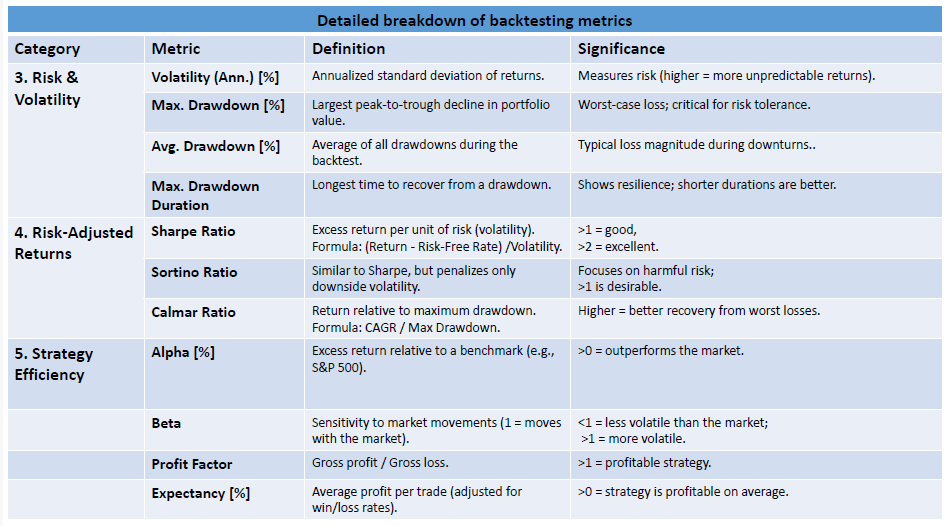

In [ ]:
from IPython.display import Image

Image(filename=r"Documents\Strategy Metrics 1.PNG")

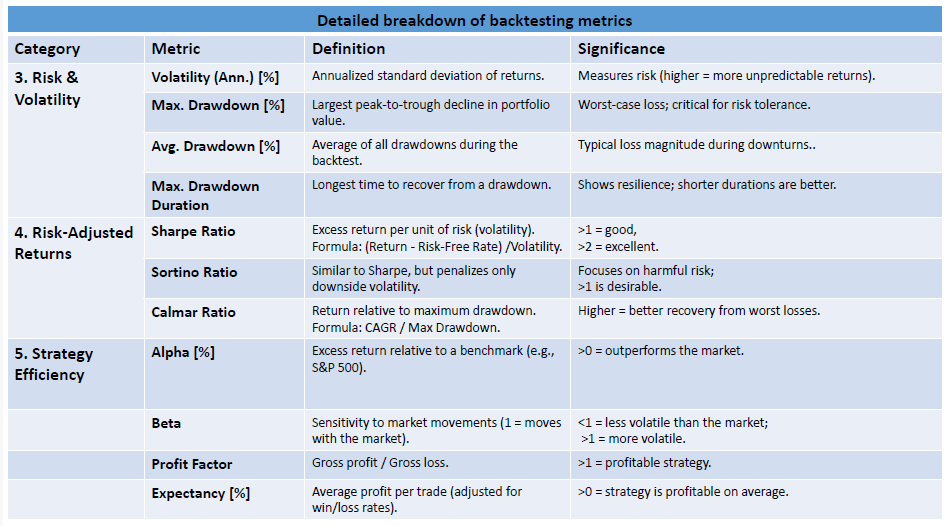

In [10]:
Image(filename=r"Documents\Strategy Metrics 2.PNG")

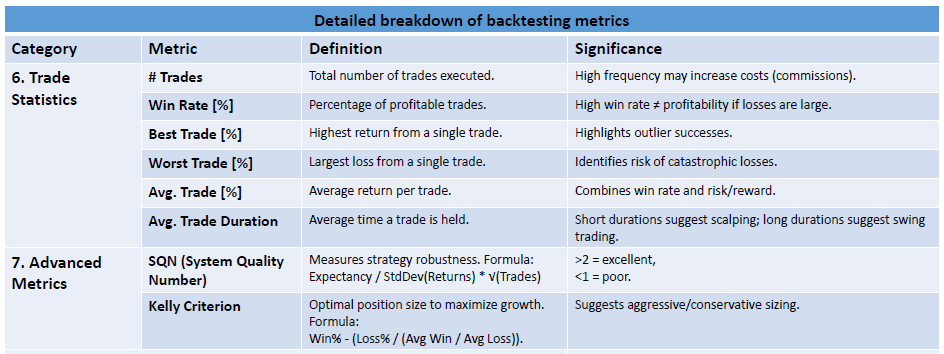

In [11]:
Image(filename=r"Documents\Strategy Metrics 3.PNG")

In [20]:
bt.plot()

GridPlot(id='p1377', ...)

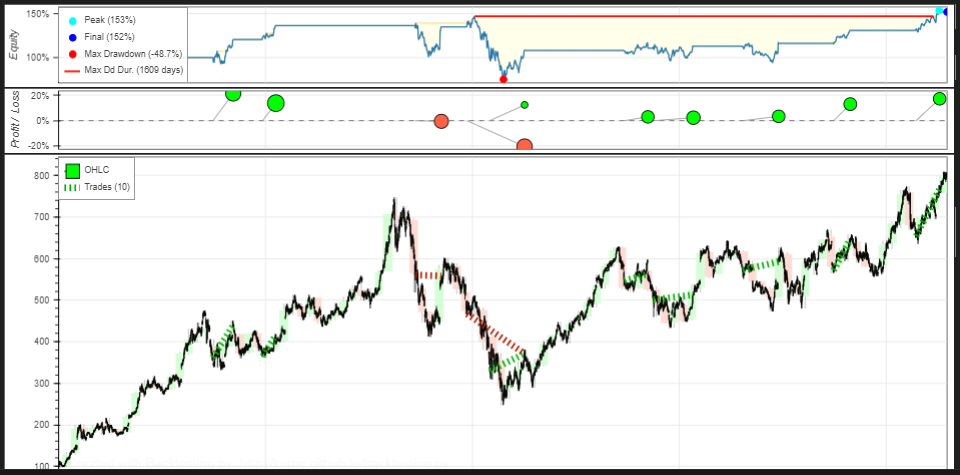

In [22]:
Image(filename=r"Documents\EquityCurve1.PNG")